In [38]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


def encontrar_raiz_proyecto() -> Path:
    """
    Localiza la raíz del repositorio independientemente
    de la carpeta desde la que se inició Jupyter.
    """
    actual = Path.cwd().resolve()

    for candidato in (actual, *actual.parents):
        if (
            (candidato / "docker-compose.yml").is_file()
            and (candidato / "src").is_dir()
            and (candidato / "notebooks").is_dir()
        ):
            return candidato

    raise FileNotFoundError(
        "No fue posible encontrar la raíz del proyecto. "
        "Abre el notebook desde el repositorio."
    )


PROJECT_ROOT = encontrar_raiz_proyecto()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.preprocessing import (
    cargar_dataset_desde_api,
    generar_resumen_calidad,
    limpiar_dataset,
)

from src.visualizations import (
    graficar_correlaciones,
    graficar_dispersion,
    graficar_evolucion_mp25,
    graficar_mp25_por_comuna,
    graficar_mp25_por_region,
    graficar_ranking_sensores,
)


print(f"Raíz del proyecto: {PROJECT_ROOT}")
print("Importaciones correctas")

Raíz del proyecto: C:\Users\yvl\Documents\GitHub\air-quality-monitoring-platform
Importaciones correctas


# Análisis exploratorio de calidad del aire

Este notebook analiza las mediciones ambientales obtenidas desde la API del proyecto, revisando calidad de datos, distribución de contaminantes, evolución temporal y diferencias territoriales.

In [39]:
ESTADO_DATOS = "provisionales"
FUENTE_DATOS = "api"

API_DATASET_URL = (
    "http://localhost:8000"
    "/analytics/dataset-modelado"
)

df_original = cargar_dataset_desde_api(
    api_url=API_DATASET_URL,
    limit=1000,
    timeout=60,
)

columnas_esperadas = [
    "fecha_hora",
    "comuna",
    "region",
    "codigo_estacion",
    "tipo_sensor",
    "mp25",
    "mp10",
    "so2",
    "no2",
    "velocidad_viento",
    "direccion_viento_grados",
    "temperatura",
    "humedad",
    "indice_vulnerabilidad_respiratoria",
    "emision_maxima_permitida",
    "categoria_ica",
]

columnas_faltantes = [
    columna
    for columna in columnas_esperadas
    if columna not in df_original.columns
]

if df_original.empty:
    raise ValueError(
        "La API devolvió un dataset vacío."
    )

if columnas_faltantes:
    raise ValueError(
        "Faltan columnas requeridas: "
        + ", ".join(columnas_faltantes)
    )

df = limpiar_dataset(df_original)

duplicados_eliminados = (
    len(df_original) - len(df)
)

print("Fuente: API paginada con datos integrados por el ETL")
print(f"Filas obtenidas desde la API: {len(df_original)}")
print(f"Filas después de la limpieza: {len(df)}")
print(f"Duplicados eliminados: {duplicados_eliminados}")
print(f"Columnas después de la limpieza: {len(df.columns)}")
print(f"Fecha inicial: {df['fecha_hora'].min()}")
print(f"Fecha final: {df['fecha_hora'].max()}")
print(f"Regiones: {df['region'].nunique()}")
print(f"Comunas: {df['comuna'].nunique()}")
print(f"Estaciones: {df['codigo_estacion'].nunique()}")

df.head()

Registros descargados: 1000
Registros descargados: 2000
Registros descargados: 3000
Registros descargados: 4000
Registros descargados: 5000
Registros descargados: 6000
Registros descargados: 7000
Registros descargados: 8000
Registros descargados: 9000
Registros descargados: 10000
Registros descargados: 11000
Registros descargados: 12000
Registros descargados: 13000
Registros descargados: 14000
Registros descargados: 15000
Registros descargados: 16000
Registros descargados: 17000
Registros descargados: 18000
Registros descargados: 19000
Registros descargados: 20000
Registros descargados: 21000
Registros descargados: 22000
Registros descargados: 23000
Registros descargados: 24000
Registros descargados: 25000
Registros descargados: 26000
Registros descargados: 26693
Fuente: API paginada con datos integrados por el ETL
Filas obtenidas desde la API: 26693
Filas después de la limpieza: 26622
Duplicados eliminados: 71
Columnas después de la limpieza: 22
Fecha inicial: 2026-01-06 00:00:00
Fech

,fecha_hora,comuna,region,codigo_estacion,tipo_sensor,mp25,mp10,so2,no2,velocidad_viento,...,humedad,indice_vulnerabilidad_respiratoria,emision_maxima_permitida,categoria_ica,fecha,anio,mes,dia,hora,dia_semana
0,2026-01-06 00:00:00,Rancagua,O'Higgins,SEN-RAN-OF-001,publico_oficial,52.4,88.1,17.3,31.0,1.2,...,88.0,61.5,320.0,Regular,2026-01-06,2026,1,6,0,Tuesday
1,2026-01-06 06:00:00,Rancagua,O'Higgins,SEN-RAN-OF-001,publico_oficial,49.8,84.4,16.8,29.6,1.5,...,91.0,61.5,320.0,Buena,2026-01-06,2026,1,6,6,Tuesday
2,2026-01-06 12:00:00,Rancagua,O'Higgins,SEN-RAN-OF-001,publico_oficial,28.5,54.2,14.1,24.7,4.6,...,61.0,61.5,320.0,Buena,2026-01-06,2026,1,6,12,Tuesday
3,2026-01-06 18:00:00,Rancagua,O'Higgins,SEN-RAN-OF-001,publico_oficial,45.2,76.3,15.9,28.3,2.8,...,74.0,61.5,320.0,Buena,2026-01-06,2026,1,6,18,Tuesday
4,2026-02-06 00:00:00,Talca,Maule,SEN-TAL-OF-001,publico_oficial,61.7,97.5,13.6,27.4,1.0,...,92.0,64.2,420.0,Regular,2026-02-06,2026,2,6,0,Friday


In [40]:
resumen_calidad = generar_resumen_calidad(df)
display(resumen_calidad)

,columna,tipo,nulos,porcentaje_nulos,valores_unicos
0,fecha_hora,datetime64[us],0,0.00,753
1,comuna,string,0,0.00,27
2,region,string,0,0.00,4
3,codigo_estacion,string,0,0.00,44
4,tipo_sensor,string,0,0.00,2
5,mp25,float64,0,0.00,1195
6,mp10,float64,0,0.00,9272
7,so2,float64,0,0.00,91
8,no2,float64,0,0.00,79
9,velocidad_viento,float64,0,0.00,133


In [41]:
print(f"Fecha inicial: {df['fecha_hora'].min()}")
print(f"Fecha final: {df['fecha_hora'].max()}")
print(f"Regiones: {df['region'].nunique()}")
print(f"Comunas: {df['comuna'].nunique()}")
print(f"Estaciones: {df['codigo_estacion'].nunique()}")

display(
    df["categoria_ica"]
    .value_counts(dropna=False)
    .rename_axis("categoria_ica")
    .reset_index(name="cantidad")
)

Fecha inicial: 2026-01-06 00:00:00
Fecha final: 2026-12-09 00:00:00
Regiones: 4
Comunas: 27
Estaciones: 44


,categoria_ica,cantidad
0,Buena,17692
1,Regular,6834
2,Alerta,1545
3,Preemergencia,536
4,Emergencia,15


In [42]:
variables_ambientales = [
    "mp25",
    "mp10",
    "so2",
    "no2",
    "velocidad_viento",
    "direccion_viento_grados",
    "temperatura",
    "humedad",
    "indice_vulnerabilidad_respiratoria",
    "emision_maxima_permitida",
]

variables_disponibles = [
    columna
    for columna in variables_ambientales
    if columna in df.columns
]

display(
    df[variables_disponibles]
    .describe()
    .transpose()
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
mp25,26622.0,45.61,23.45,9.00,29.90,37.40,60.75,178.05
mp10,26622.0,102.61,44.15,29.66,70.77,88.60,131.35,331.25
so2,26622.0,30.92,14.51,10.70,19.00,25.00,41.00,310.00
no2,26622.0,48.16,12.42,20.80,39.00,45.00,58.00,86.00
velocidad_viento,26622.0,3.16,1.61,0.35,1.86,2.69,4.55,6.37
direccion_viento_grados,26622.0,180.44,104.28,0.00,90.00,181.00,271.00,360.00
temperatura,26622.0,13.15,6.02,2.90,8.46,12.90,17.60,26.50
humedad,26622.0,72.29,16.68,38.00,61.00,76.00,84.00,98.00
indice_vulnerabilidad_respiratoria,26622.0,67.37,5.34,54.80,63.20,67.80,72.70,76.20
emision_maxima_permitida,24536.0,297.16,165.86,90.00,155.00,260.00,420.00,650.00


## Análisis territorial de MP2.5

Se comparan las concentraciones promedio de MP2.5 entre comunas y regiones para identificar las zonas con mayores niveles de contaminación.

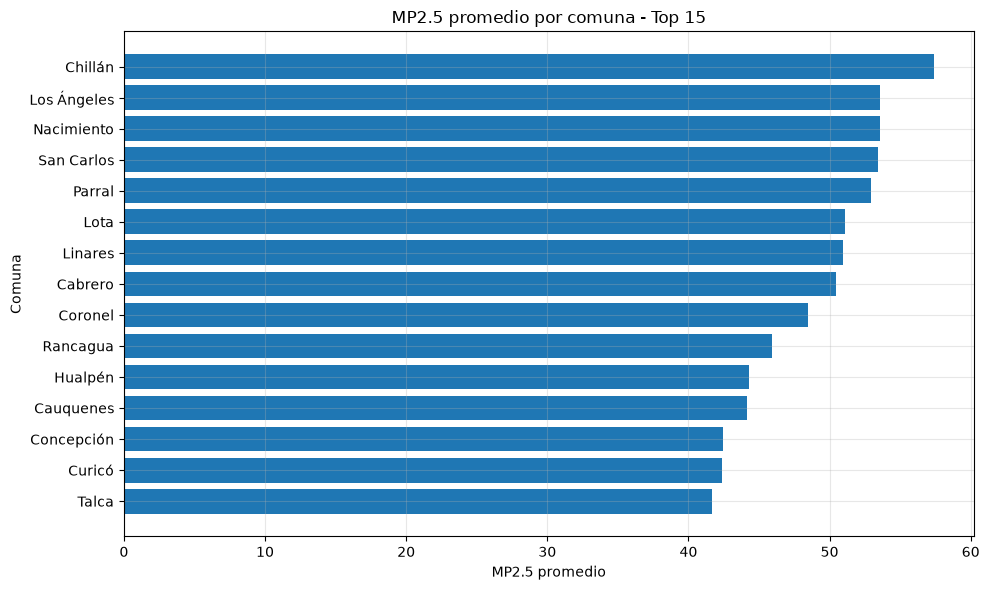

,comuna,region,mp25_promedio,mp25_maximo,cantidad_mediciones
4,Chillán,Ñuble,57.36,176.05,2139
12,Los Ángeles,Biobío,53.57,178.05,1766
16,Nacimiento,Biobío,53.56,172.05,674
20,San Carlos,Ñuble,53.40,171.05,1411
17,Parral,Maule,52.96,170.05,674
13,Lota,Biobío,51.07,125.05,674
11,Linares,Maule,50.98,168.05,1347
2,Cabrero,Biobío,50.45,167.05,674
8,Coronel,Biobío,48.49,126.05,1766
19,Rancagua,O'Higgins,45.91,118.05,2140


In [43]:
figura, ax = graficar_mp25_por_comuna(df, top_n=15)
plt.show()

ranking_comunas = (
    df.groupby(["comuna", "region"], as_index=False)
    .agg(
        mp25_promedio=("mp25", "mean"),
        mp25_maximo=("mp25", "max"),
        cantidad_mediciones=("mp25", "count"),
    )
    .sort_values("mp25_promedio", ascending=False)
)

display(ranking_comunas.head(10).round(2))

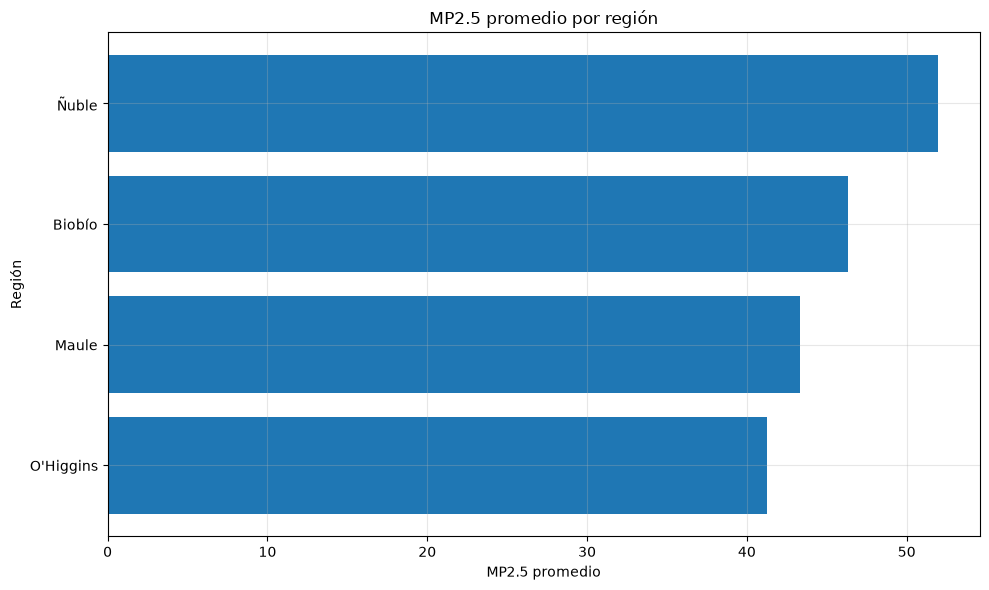

,region,mp25_promedio,mp25_maximo,cantidad_mediciones
3,Ñuble,51.99,176.05,4276
0,Biobío,46.33,178.05,10804
1,Maule,43.35,170.05,7272
2,O'Higgins,41.28,118.05,4270


In [44]:
figura, ax = graficar_mp25_por_region(df)
plt.show()

ranking_regiones = (
    df.groupby("region", as_index=False)
    .agg(
        mp25_promedio=("mp25", "mean"),
        mp25_maximo=("mp25", "max"),
        cantidad_mediciones=("mp25", "count"),
    )
    .sort_values("mp25_promedio", ascending=False)
)

display(ranking_regiones.round(2))

## Evolución temporal y días críticos

Se analiza cómo cambia el MP2.5 en el tiempo y se identifican las fechas con mayores concentraciones promedio.

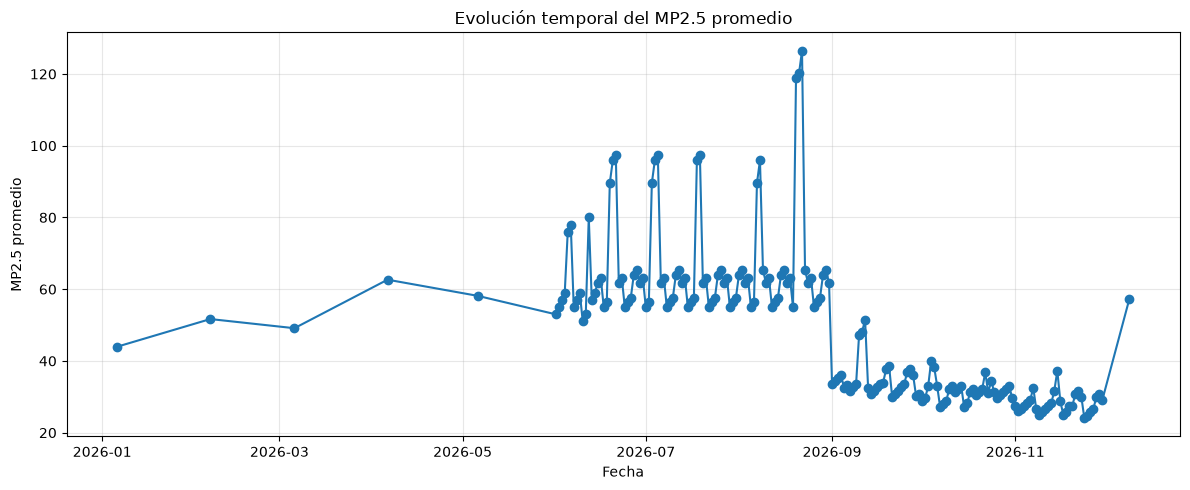

,fecha,mp25_promedio,mp25_maximo,cantidad_mediciones
87,2026-08-22,126.49,178.05,128
86,2026-08-21,120.14,171.70,128
85,2026-08-20,118.79,170.35,128
53,2026-07-19,97.28,133.40,128
25,2026-06-21,97.28,133.40,128
39,2026-07-05,97.28,133.40,128
38,2026-07-04,95.92,132.05,128
24,2026-06-20,95.92,132.05,128
52,2026-07-18,95.92,132.05,128
73,2026-08-08,95.92,132.05,128


In [45]:
figura, ax = graficar_evolucion_mp25(df, frecuencia="D")
plt.show()

dias_criticos = (
    df.groupby("fecha", as_index=False)
    .agg(
        mp25_promedio=("mp25", "mean"),
        mp25_maximo=("mp25", "max"),
        cantidad_mediciones=("mp25", "count"),
    )
    .sort_values("mp25_promedio", ascending=False)
)

display(dias_criticos.head(10).round(2))

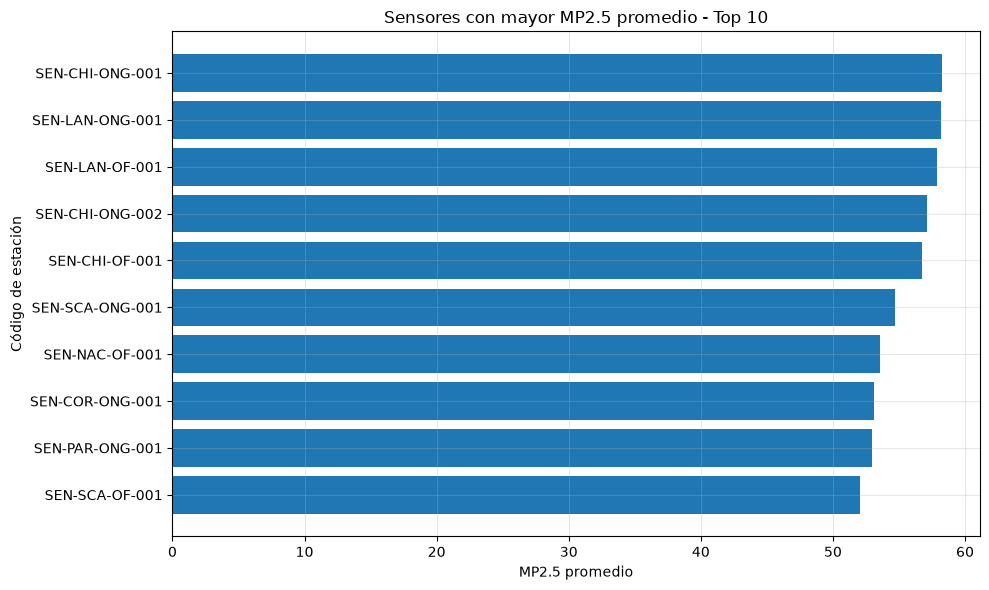

,codigo_estacion,comuna,tipo_sensor,mp25_promedio,mp25_maximo,cantidad_mediciones
5,SEN-CHI-ONG-001,Chillán,sensor_comunitario_ong,58.22,176.05,731
20,SEN-LAN-ONG-001,Los Ángeles,sensor_comunitario_ong,58.20,178.05,675
19,SEN-LAN-OF-001,Los Ángeles,publico_oficial,57.85,176.05,730
6,SEN-CHI-ONG-002,Chillán,sensor_comunitario_ong,57.15,176.05,674
4,SEN-CHI-OF-001,Chillán,publico_oficial,56.71,174.05,734
34,SEN-SCA-ONG-001,San Carlos,sensor_comunitario_ong,54.66,171.05,732
27,SEN-NAC-OF-001,Nacimiento,publico_oficial,53.56,172.05,674
12,SEN-COR-ONG-001,Coronel,sensor_comunitario_ong,53.09,126.05,731
28,SEN-PAR-ONG-001,Parral,sensor_comunitario_ong,52.96,170.05,674
33,SEN-SCA-OF-001,San Carlos,publico_oficial,52.04,169.05,679


In [46]:
figura, ax = graficar_ranking_sensores(df, top_n=10)
plt.show()

ranking_sensores = (
    df.groupby(
        ["codigo_estacion", "comuna", "tipo_sensor"],
        as_index=False,
    )
    .agg(
        mp25_promedio=("mp25", "mean"),
        mp25_maximo=("mp25", "max"),
        cantidad_mediciones=("mp25", "count"),
    )
    .sort_values("mp25_promedio", ascending=False)
)

display(ranking_sensores.head(10).round(2))

## Relación entre meteorología y contaminación

Se estudia la relación entre MP2.5 y variables meteorológicas como humedad, temperatura y velocidad del viento.

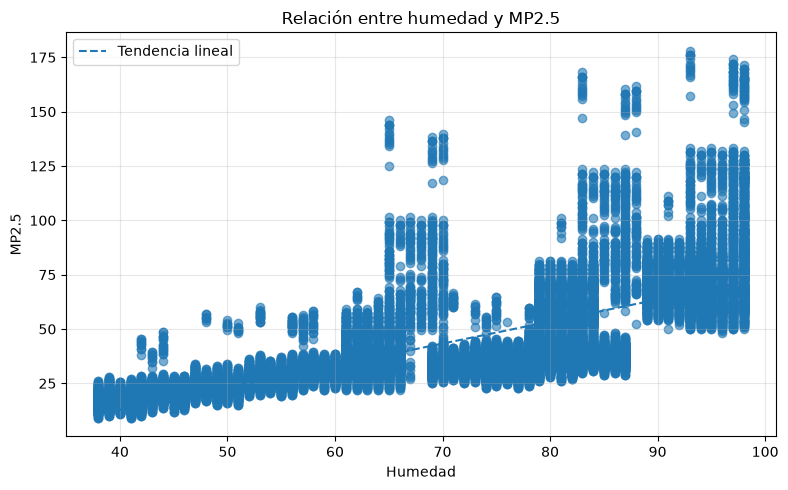

In [47]:
figura, ax = graficar_dispersion(
    df,
    variable_x="humedad",
    titulo="Relación entre humedad y MP2.5",
)
plt.show()

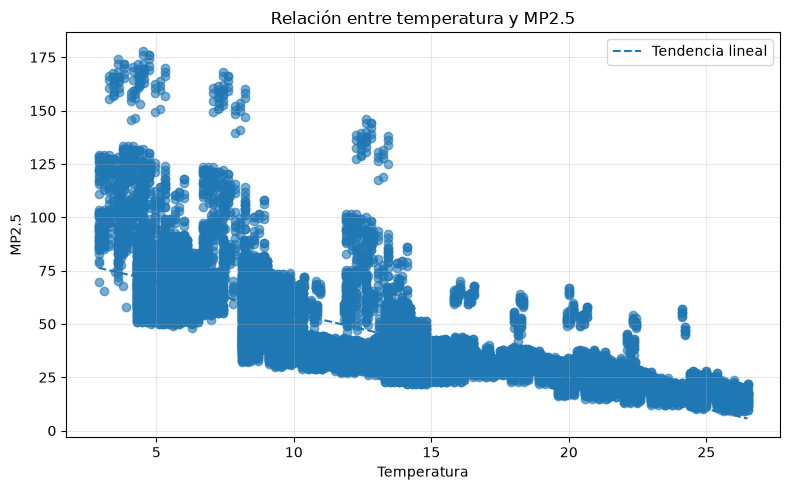

In [48]:
figura, ax = graficar_dispersion(
    df,
    variable_x="temperatura",
    titulo="Relación entre temperatura y MP2.5",
)
plt.show()

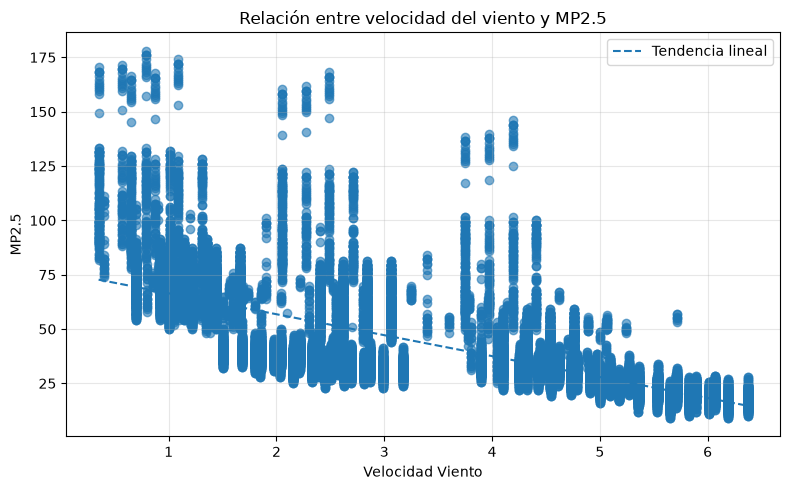

In [49]:
figura, ax = graficar_dispersion(
    df,
    variable_x="velocidad_viento",
    titulo="Relación entre velocidad del viento y MP2.5",
)
plt.show()

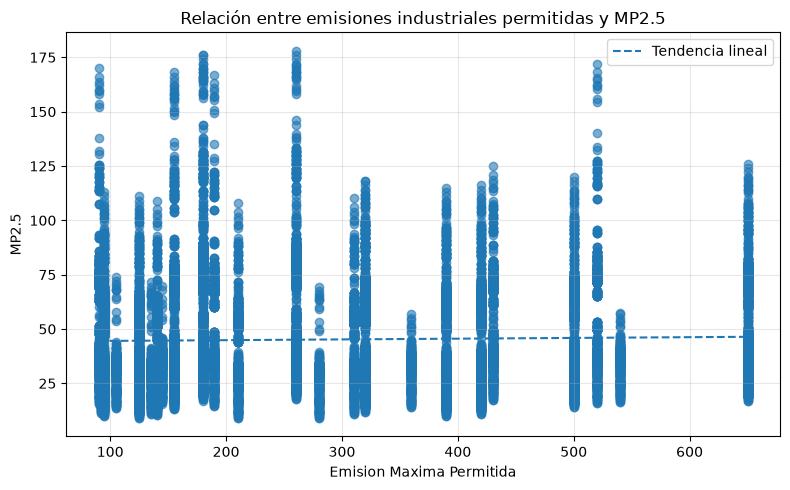

In [50]:
if (
    "emision_maxima_permitida" in df.columns
    and df["emision_maxima_permitida"].notna().any()
):
    figura, ax = graficar_dispersion(
        df,
        variable_x="emision_maxima_permitida",
        titulo="Relación entre emisiones industriales permitidas y MP2.5",
    )
    plt.show()
else:
    print(
        "No existen suficientes datos de emisiones industriales "
        "para generar este gráfico."
    )

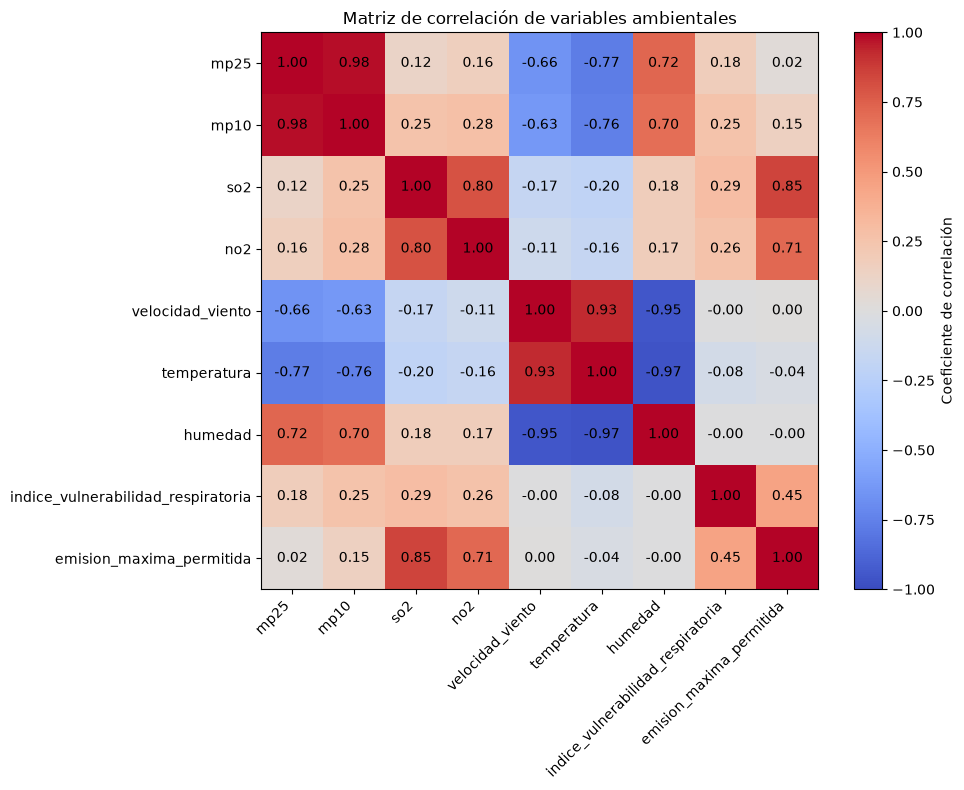

In [51]:
figura, ax = graficar_correlaciones(df)
plt.show()

## Conclusiones del análisis exploratorio

El dataset final utilizado en este análisis contiene **26.622 registros procesados**, cubre el periodo entre el **6 de enero de 2026** y el **9 de diciembre de 2026**, e incluye mediciones para **4 regiones**, **27 comunas** y **44 estaciones**.

### Distribución territorial

A nivel comunal, las mayores concentraciones promedio de MP2.5 se observan en:

1. **Chillán**, con un promedio de **57.36**.
2. **Los Ángeles**, con un promedio de **53.57**.
3. **Nacimiento**, con un promedio de **53.56**.
4. **San Carlos**, con un promedio de **53.40**.
5. **Parral**, con un promedio de **52.96**.

A nivel regional, **Ñuble** presenta el mayor promedio de MP2.5, con **51.99**, seguida por **Biobío** con **46.33**, **Maule** con **43.35** y **O'Higgins** con **41.28**.

Esto sugiere que las zonas de Ñuble y algunas comunas del Biobío concentran los mayores niveles promedio de material particulado fino dentro del caso de estudio.

### Evolución temporal

Los días con mayores niveles promedio de MP2.5 se concentran principalmente en invierno. El día más crítico fue el **22 de agosto de 2026**, con un promedio diario de **126.49** y un máximo de **178.05**.

También destacan el **21 de agosto** y el **20 de agosto**, con promedios de **120.14** y **118.79**, respectivamente. Esto refuerza la presencia de un patrón estacional, donde los episodios más críticos ocurren durante meses fríos.

### Relación entre variables

La correlación más alta se observa entre **MP2.5 y MP10**, con un valor de **0.980**. Esto indica que ambas variables se comportan de forma muy similar dentro del dataset, por lo que usar ambas simultáneamente en clustering podría introducir información redundante.

MP2.5 también presenta una correlación positiva importante con la **humedad**, con **0.721**. En cambio, presenta correlaciones negativas con:

* **temperatura**, con **-0.769**;
* **velocidad del viento**, con **-0.661**.

Esto es coherente con escenarios donde menores temperaturas y menor ventilación se asocian a mayores concentraciones de material particulado.

Las variables **SO2**, **NO2**, **emisión máxima permitida** e **índice de vulnerabilidad respiratoria** muestran correlaciones más bajas con MP2.5. Sin embargo, siguen siendo útiles para el modelamiento porque aportan información complementaria sobre contaminación gaseosa, contexto industrial y vulnerabilidad territorial.

### Implicancias para el clustering

Para el clustering no conviene usar todas las variables disponibles sin criterio, porque algunas presentan alta redundancia. En particular, MP10 se comporta de manera muy similar a MP2.5.

Por eso, para el modelo de agrupamiento se recomienda utilizar variables que representen dimensiones distintas del problema:

* nivel de contaminación por MP2.5;
* contaminantes gaseosos como SO2 y NO2;
* velocidad del viento como indicador de dispersión;
* vulnerabilidad respiratoria;
* contexto industrial mediante emisión máxima permitida.

Los resultados del EDA permiten justificar la selección de variables para construir perfiles de riesgo ambiental mediante K-Means.

### Limitaciones

Las fuentes utilizadas corresponden a un caso académico con datos simulados. Por lo tanto, los resultados permiten validar el flujo técnico de análisis, pero no deben interpretarse como mediciones ambientales oficiales actuales ni como evidencia causal.
